In [1]:
library(biomaRt)
library(coloc)
library(vroom)
library(stringr)
library(dplyr)
library(ggplot2)
library(parallel)
library(ggplot2)
#library(nationalparkcolors)
library(SNPlocs.Hsapiens.dbSNP155.GRCh38)

This is coloc version 5.2.3


Attaching package: ‘dplyr’


The following object is masked from ‘package:biomaRt’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: BSgenome

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tap

# Convert GWAS to hg38

In [4]:
sum.stats <- vroom('/nfs/lab/MVP/NAFLD.EUR.MVP.2021.txt.gz')

dim(sum.stats)
head(sum.stats)

Rows: 11691992 Columns: 11
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr (3): RSID, EA, NEA
dbl (8): CHR, POS, EAF, BETA, SE, P, N, OR

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 11691992       11

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001


In [18]:
sum.stats.filt <- sum.stats[str_detect(sum.stats$RSID, 'rs'),]
dim(sum.stats.filt)
head(sum.stats.filt)

[1] 11671303       11

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001


In [7]:
snps <- SNPlocs.Hsapiens.dbSNP155.GRCh38
snpcount(snps)
seqinfo(snps)

1        2        3        4        5        6        7        8 
75018827 79800406 65297222 62943150 58975130 54890615 52513853 49808065 
       9       10       11       12       13       14       15       16 
41429208 43919217 45144118 43436160 32601707 29144464 27215990 29493439 
      17       18       19       20       21       22        X        Y 
26217755 25582976 19590577 20830213 12400011 12798923 37808263  2153980 
      MT 
    7179

Seqinfo object with 25 sequences (1 circular) from GRCh38.p13 genome:
  seqnames seqlengths isCircular     genome
  1         248956422      FALSE GRCh38.p13
  2         242193529      FALSE GRCh38.p13
  3         198295559      FALSE GRCh38.p13
  4         190214555      FALSE GRCh38.p13
  5         181538259      FALSE GRCh38.p13
  ...             ...        ...        ...
  21         46709983      FALSE GRCh38.p13
  22         50818468      FALSE GRCh38.p13
  X         156040895      FALSE GRCh38.p13
  Y          57227415      FALSE GRCh38.p13
  MT            16569       TRUE GRCh38.p13

In [20]:
my_snps <- snpsById(snps, sum.stats.filt$RSID, ifnotfound='warning')
my_snps

Warning message in rowids2rowidx(user_rowids, ids, x_rowids_env, ifnotfound):
“SNP ids not found: rs77438462, rs55693913, rs140940347, rs74720269,
  rs74478601, rs371529763, rs9727735, rs145403487, rs139262276, ...
  
  They were dropped.”


UnstitchedGPos object with 11657619 positions and 2 metadata columns:
             seqnames       pos strand |   RefSNP_id alleles_as_ambig
                <Rle> <integer>  <Rle> | <character>      <character>
         [1]        1    494511      * | rs542222769                Y
         [2]        1    791782      * | rs559154412                Y
         [3]        1    812952      * | rs182373484                Y
         [4]        1    815963      * |  rs28544273                W
         [5]        1    816376      * |  rs28527770                Y
         ...      ...       ...    ... .         ...              ...
  [11657615]       22  50781660      * | rs566371895                V
  [11657616]       22  50782089      * |   rs9616980                B
  [11657617]       22  50788264      * | rs150189434                R
  [11657618]       22  50790203      * | rs531249897                H
  [11657619]       22  50796371      * | rs191117135                D
  -------
  seqinfo:

In [23]:
my_snps.df <- select(data.frame(my_snps), RSID=RefSNP_id, chr.hg38=seqnames, pos.hg38=pos)

dim(my_snps.df)
head(my_snps.df)

[1] 11657619        3

,RSID,chr.hg38,pos.hg38
,<chr>,<fct>,<int>
1,rs542222769,1,494511
2,rs559154412,1,791782
3,rs182373484,1,812952
4,rs28544273,1,815963
5,rs28527770,1,816376
6,rs3094315,1,817186


In [24]:
sum.stats.hg38 <- inner_join(sum.stats.filt, my_snps.df)

dim(sum.stats.hg38)
head(sum.stats.hg38)

Joining with `by = join_by(RSID)`
Warning message in inner_join(sum.stats.filt, my_snps.df):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 5879577 of `x` matches multiple rows in `y`.
ℹ Row 5872341 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.”


[1] 11657625       13

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186


In [25]:
write.table(sum.stats.hg38, '/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.hg38.tsv',
           sep='\t', col.names=T, row.names=F, quote=F)

# Coloc

In [ ]:
### save this as coloc.NAFLD.R in /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas

library(coloc)
library(vroom)
library(stringr)
library(dplyr)
library(ggplot2)

args = commandArgs(trailingOnly=TRUE)

mod <- args[1]
cell <- args[2]

mod.subdirs <- list(RNA='04_eQTLs',
                   ATAC='05_caQTLs',
                   H3K27ac='06_H3K27acQTLs',
                   H3K27me3='07_H3K27me3QTLs')

results.df <- data.frame()

sum.stats.hg38 <- vroom('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/gwas.sum.stats/NAFLD.EUR.MVP.2021.hg38.tsv',
           delim='\t')

#dim(sum.stats.hg38)
#head(sum.stats.hg38)

#for (mod in modalities) {
# cell <- 'B' # for debugging
#for (cell in cells) {
message(paste0("Starting ", cell))
message(Sys.time())

# Read in count data
count.path <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/',mod.subdirs[[mod]],'/counts/',
                                 cell,'_perdonor.',mod,'.INT.bed')
counts <- read.table(count.path)

# Get standard deviations
counts.sd <- tibble::column_to_rownames(counts, var='V4')
counts.sd <- select(counts.sd, -V1, -V2, -V3)
sdY.vect <- apply(counts.sd, 1, sd, na.rm=TRUE)

# Read in feature level summary stats to select features/chromosomes to coloc
feature.res.path <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/',mod.subdirs[[mod]],'/outs/',
                                 cell,'.qvalue.cis_qtl.txt.gz')
qtl.feature.res <- read.table(feature.res.path, header=T)
qtl.feature.res <- left_join(qtl.feature.res,select(counts, phenotype_id=V4, chr=V1), by = join_by(phenotype_id))
qtl.feature.res <- filter(qtl.feature.res, qval < 0.05)

gc()
#chr <- 'chr11' # Debug option
for (chr in unique(qtl.feature.res$chr)) {
    message(paste("Starting ", chr))
    message(Sys.time())
    # Read in pairwise summary stats. We are going by chr to reduce server usage
    qtl.sum.stats <- read.table(paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/tsv.test/',
                     cell, '.cis_qtl_pairs.',chr,'.parquet.tsv'), header=T)
    qtl.sum.stats <- qtl.sum.stats[str_detect(qtl.sum.stats$variant_id, 'rs'),]
    
    # Join with GWAS results by rsID. Some variants are lost, but we can only compare the inner join
    joined.sumstats <- inner_join(qtl.sum.stats, sum.stats.hg38, by=join_by(variant_id == RSID))
    
    # Get a list of features taht are significant
    sig.chr.features <- qtl.feature.res[qtl.feature.res$chr == chr,]$phenotype_id
    
    gc()
    #feat <- sig.chr.features[1] # Debug option
    for (feat in sig.chr.features) {
        gc()
        # subset data and create coloc objects
        feat.sumstats <- dplyr::filter(joined.sumstats, phenotype_id == feat)
        
        qtl.data <- list(beta=feat.sumstats$slope,
                        varbeta=(feat.sumstats$slope_se)^2,
                        snp=feat.sumstats$variant_id,
                        position=feat.sumstats$pos.hg38,
                        type='quant',
                        sdY=sdY.vect[[feat]])
        
        gwas.data <- list(beta=feat.sumstats$BETA,
                        varbeta=(feat.sumstats$SE)^2,
                        snp=feat.sumstats$variant_id,
                        position=feat.sumstats$pos.hg38,
                        type='cc')
        
        # Run coloc
        coloc.res <- coloc.abf(dataset1=qtl.data,
                               dataset2=gwas.data)
        
        # Grab some info on lead signals to save with coloc
        qtl.lead <- arrange(feat.sumstats, pval_nominal, abs(start_distance)) %>%
            select(qtl.lead=variant_id,qtl.pval=pval_nominal, qtl.pos=pos.hg38)
        qtl.lead <- qtl.lead[1,]
        
        gwas.lead <- arrange(feat.sumstats, P) %>%
            select(gwas.lead=variant_id,gwas.pval=P, qtl.pos=pos.hg38)
        gwas.lead <- gwas.lead[1,]
        
        results.df <- rbind(results.df, data.frame(rbind(coloc.res$summary), cell=cell, modality='RNA',feature=feat,
                  qtl.lead,gwas.lead))
        gc()
    }
}
gc()

write.table(results.df, paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/coloc.res/',mod,
                              '.',cell,'.color.abf.results.tsv'), sep='\t', quote=F, col.names=T, row.names=F)

dim(results.df)
head(results.df)

##### In bash on TSCC  

cd /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas
conda activate coloc.susie

for mod in RNA ATAC H3K27ac H3K27me3; do
    for cell in B Bulk Cholangiocyte Endothelial Hepatocytes HSC Myeloid NK T; do
        srun --output=log/$mod.$cell.log --error=log/$mod.$cell.err --nodes=1 --ntasks-per-node=1 --cpus-per-task=4 --mem=128G --account=csd854 -t 00:60:00 -p condo -q condo Rscript --vanilla coloc.NAFLD.R $mod $cell &
        sleep 10
    done
done

# Read Results

In [2]:
sum.stats.hg38 <- vroom('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.hg38.tsv',
           delim='\t')

dim(sum.stats.hg38)
head(sum.stats.hg38)

Rows: 11657625 Columns: 13
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): RSID, EA, NEA
dbl (10): CHR, POS, EAF, BETA, SE, P, N, OR, chr.hg38, pos.hg38

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 11657625       13

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186


In [8]:
coloc.results.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/coloc.res/'
files <- list.files(coloc.results.dir, pattern='coloc.abf.results.tsv')
files

[1] "ATAC.B.coloc.abf.results.tsv"                
 [2] "ATAC.Bulk.coloc.abf.results.tsv"             
 [3] "ATAC.Cholangiocyte.coloc.abf.results.tsv"    
 [4] "ATAC.Endothelial.coloc.abf.results.tsv"      
 [5] "ATAC.Hepatocytes.coloc.abf.results.tsv"      
 [6] "ATAC.HSC.coloc.abf.results.tsv"              
 [7] "ATAC.Myeloid.coloc.abf.results.tsv"          
 [8] "ATAC.NK.coloc.abf.results.tsv"               
 [9] "ATAC.T.coloc.abf.results.tsv"                
[10] "H3K27ac.B.coloc.abf.results.tsv"             
[11] "H3K27ac.Bulk.coloc.abf.results.tsv"          
[12] "H3K27ac.Cholangiocyte.coloc.abf.results.tsv" 
[13] "H3K27ac.Endothelial.coloc.abf.results.tsv"   
[14] "H3K27ac.Hepatocytes.coloc.abf.results.tsv"   
[15] "H3K27ac.HSC.coloc.abf.results.tsv"           
[16] "H3K27ac.Myeloid.coloc.abf.results.tsv"       
[17] "H3K27ac.NK.coloc.abf.results.tsv"            
[18] "H3K27ac.T.coloc.abf.results.tsv"             
[19] "H3K27me3.B.coloc.abf.results.tsv"            
[20] "H3K27me3.Bulk.coloc.abf.results.tsv"         
[21] "H3K27me3.Cholangiocyte.coloc.abf.results.tsv"
[22] "H3K27me3.Endothelial.coloc.abf.results.tsv"  
[23] "H3K27me3.Hepatocytes.coloc.abf.results.tsv"  
[24] "H3K27me3.HSC.coloc.abf.results.tsv"          
[25] "H3K27me3.Myeloid.coloc.abf.results.tsv"      
[26] "H3K27me3.NK.coloc.abf.results.tsv"           
[27] "H3K27me3.T.coloc.abf.results.tsv"            
[28] "RNA.B.coloc.abf.results.tsv"                 
[29] "RNA.Bulk.coloc.abf.results.tsv"              
[30] "RNA.Cholangiocyte.coloc.abf.results.tsv"     
[31] "RNA.Endothelial.coloc.abf.results.tsv"       
[32] "RNA.Hepatocytes.coloc.abf.results.tsv"       
[33] "RNA.HSC.coloc.abf.results.tsv"               
[34] "RNA.Myeloid.coloc.abf.results.tsv"           
[35] "RNA.NK.coloc.abf.results.tsv"                
[36] "RNA.T.coloc.abf.results.tsv"

In [10]:
str_split(files, '\\.', simplify=T)

ATAC,B,coloc,abf,results,tsv
ATAC,Bulk,coloc,abf,results,tsv
ATAC,Cholangiocyte,coloc,abf,results,tsv
ATAC,Endothelial,coloc,abf,results,tsv
ATAC,Hepatocytes,coloc,abf,results,tsv
ATAC,HSC,coloc,abf,results,tsv
ATAC,Myeloid,coloc,abf,results,tsv
ATAC,NK,coloc,abf,results,tsv
ATAC,T,coloc,abf,results,tsv
H3K27ac,B,coloc,abf,results,tsv
H3K27ac,Bulk,coloc,abf,results,tsv


In [11]:
coloc.res <- data.frame()

for (file in files) {
    tryCatch(ct.mod.res <- read.table(paste0(coloc.results.dir, file), header=T), error=function(e) NULL)
    
    if (nrow(ct.mod.res) == 0) next
    ct.mod.res$cell <- str_split(file, '\\.', simplify=T)[2]
    ct.mod.res$modality <- str_split(file, '\\.', simplify=T)[1]
    
    coloc.res <- rbind(coloc.res, ct.mod.res)
}

dim(coloc.res)
head(coloc.res)

[1] 23238    15

,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>
1,3508,1.306176e-14,0.94618356,5.610291e-16,0.04062730,0.013189144,B,ATAC,chr12-9283821-9284121,rs7960104,6.269375e-15,9283043,rs7953214,1.004e-03,9007409
2,3638,3.977253e-05,0.90458275,3.951258e-06,0.08986154,0.005511986,B,ATAC,chr12-131682212-131682512,rs55661795,2.810744e-10,131693185,rs35628522,3.021e-04,131002122
3,1135,3.624586e-01,0.62099805,4.118456e-03,0.00705075,0.005374115,B,ATAC,chr17-20677563-20677863,rs28375463,3.363653e-06,20757517,rs11653586,1.120e-02,20907334
4,2409,3.525964e-09,0.11251489,1.593763e-08,0.50819678,0.379288309,B,ATAC,chr8-8227864-8228164,rs2001840,4.332539e-12,8261726,rs6601720,1.748e-06,8643214
5,2410,7.026802e-09,0.05019192,3.177324e-08,0.22623031,0.723577725,B,ATAC,chr8-8228311-8228611,rs13259216,4.676211e-12,8816091,rs6601720,1.748e-06,8643214
6,1667,6.976893e-01,0.13506177,1.299560e-01,0.02514531,0.012147646,B,ATAC,chr9-128192843-128193143,rs45604631,1.248834e-04,128187020,rs13297866,8.783e-06,128748127


In [14]:
sort(table(coloc.res$gwas.lead), decreasing = T)


   rs971788   rs1592800   rs1526123   rs3129754    rs632347   rs1821431 
        280         215         179         146         109         101 
  rs3129840    rs584373  rs13409360   rs1144593   rs7604422 rs116940878 
        101          92          85          82          80          74 
 rs34331968   rs1497406   rs3810367   rs5760103  rs11551684    rs687621 
         74          73          73          71          69          69 
  rs7395125  rs12041301    rs587937   rs1179630   rs1318235   rs4539629 
         68          67          67          66          65          65 
  rs4542495  rs79724799  rs35332090  rs35430572   rs7766089  rs10934753 
         65          64          61          61          61          59 
   rs406447   rs2520659   rs4493372      rs7599    rs918115   rs2721150 
         59          58          58          58          57          56 
  rs6866927  rs61662529  rs10228189   rs3824801  rs12475576   rs2299945 
         55          54          53          53   

In [15]:
length(unique(coloc.res$gwas.lead))

[1] 2131

In [16]:
filter(coloc.res, feature=='CWF19L1')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>
2929,5.857610e-113,2.184932e-100,2.680785e-13,0.9999525,4.748356e-05,Bulk,RNA,CWF19L1,rs17729876,3.498373e-13,100239989,rs10883451,3.6e-106,100164661
2929,5.646305e-110,2.184974e-100,2.584080e-10,0.9999721,2.792773e-05,Hepatocytes,RNA,CWF19L1,rs17729876,1.830849e-12,100239989,rs10883451,3.6e-106,100164661


`summarise()` has grouped output by 'modality'. You can override using the `.groups` argument.


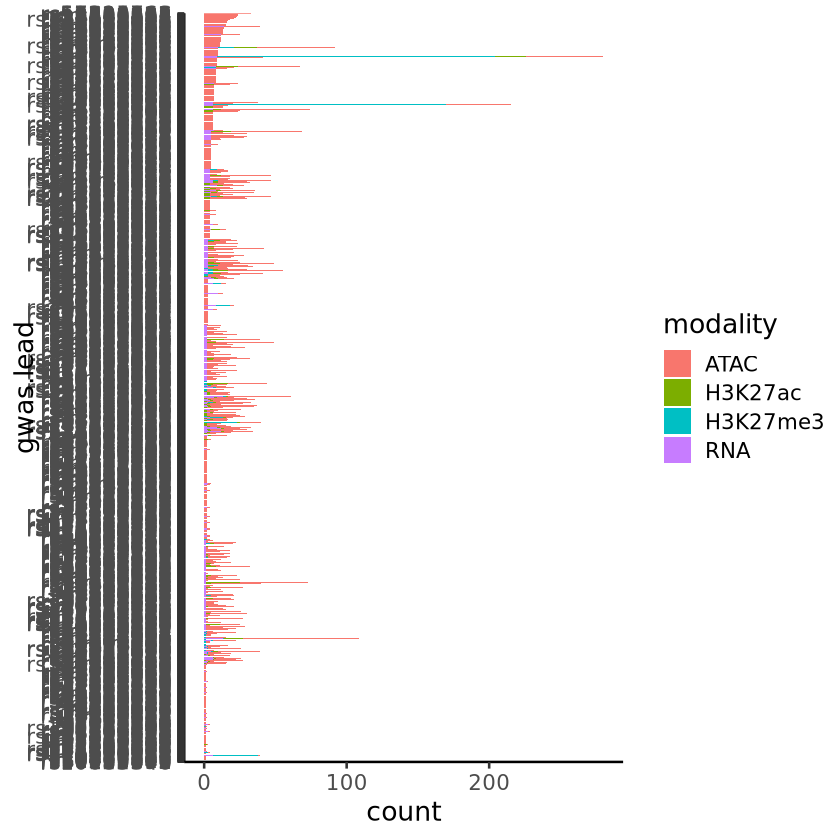

In [17]:
plot.data.var <- coloc.res %>% group_by(modality, gwas.lead) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.var$gwas.lead <- factor(plot.data.var$gwas.lead, levels=unique(plot.data.var$gwas.lead))

ggplot(plot.data.var, aes(x=gwas.lead, y=count, fill=modality)) + geom_col() + theme_classic(base_size=16)  + coord_flip()

`summarise()` has grouped output by 'modality'. You can override using the `.groups` argument.


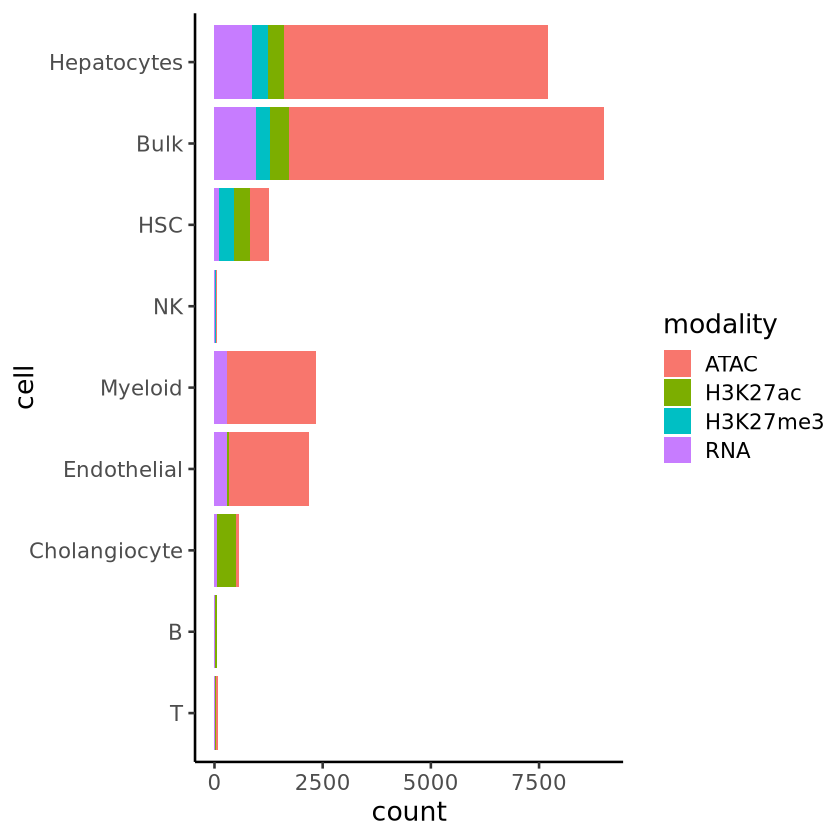

In [18]:
plot.data.ct <- coloc.res %>% group_by(modality, cell) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.ct$cell <- factor(plot.data.ct$cell, levels=unique(plot.data.ct$cell))

ggplot(plot.data.ct, aes(x=cell, y=count, fill=modality)) + geom_col() + theme_classic(base_size=16)  + coord_flip()

In [19]:
dim(coloc.res)
head(coloc.res)

[1] 23238    15

,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>
1,3508,1.306176e-14,0.94618356,5.610291e-16,0.04062730,0.013189144,B,ATAC,chr12-9283821-9284121,rs7960104,6.269375e-15,9283043,rs7953214,1.004e-03,9007409
2,3638,3.977253e-05,0.90458275,3.951258e-06,0.08986154,0.005511986,B,ATAC,chr12-131682212-131682512,rs55661795,2.810744e-10,131693185,rs35628522,3.021e-04,131002122
3,1135,3.624586e-01,0.62099805,4.118456e-03,0.00705075,0.005374115,B,ATAC,chr17-20677563-20677863,rs28375463,3.363653e-06,20757517,rs11653586,1.120e-02,20907334
4,2409,3.525964e-09,0.11251489,1.593763e-08,0.50819678,0.379288309,B,ATAC,chr8-8227864-8228164,rs2001840,4.332539e-12,8261726,rs6601720,1.748e-06,8643214
5,2410,7.026802e-09,0.05019192,3.177324e-08,0.22623031,0.723577725,B,ATAC,chr8-8228311-8228611,rs13259216,4.676211e-12,8816091,rs6601720,1.748e-06,8643214
6,1667,6.976893e-01,0.13506177,1.299560e-01,0.02514531,0.012147646,B,ATAC,chr9-128192843-128193143,rs45604631,1.248834e-04,128187020,rs13297866,8.783e-06,128748127


In [20]:
coloc.res.filt <- filter(coloc.res, PP.H4.abf > .8)

dim(coloc.res.filt)
head(coloc.res.filt)

[1] 229  15

,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>
1,2825,9.681856e-10,1.149327e-04,2.216742e-07,0.025340263,0.9745446,Bulk,ATAC,chr1-16189980-16190280,rs1497406,1.547193e-10,16178825,rs1497406,1.458e-08,16178825
2,2566,2.705990e-05,2.476040e-02,1.156288e-05,0.009614698,0.9655863,Bulk,ATAC,chr1-229256817-229257117,rs10916454,2.233151e-09,229253038,rs12041301,9.290e-06,229245010
3,5058,5.088451e-02,6.435270e-02,1.102903e-02,0.013087567,0.8606462,Bulk,ATAC,chr10-26710287-26710575,rs2477276,5.178316e-08,26666136,rs2477276,2.912e-05,26666136
4,5057,3.724166e-02,5.371677e-02,8.071817e-03,0.010752443,0.8902173,Bulk,ATAC,chr10-26711375-26711675,rs2477276,3.571726e-08,26666136,rs2477276,2.912e-05,26666136
5,2439,2.088562e-34,1.195832e-10,1.869171e-25,0.106127774,0.8938722,Bulk,ATAC,chr11-61820741-61821041,rs174576,2.043734e-17,61836038,rs174535,3.105e-15,61783884
6,2412,4.655157e-12,5.397353e-11,4.166160e-03,0.047355445,0.9484784,Bulk,ATAC,chr11-61832766-61833066,rs174576,4.284548e-07,61836038,rs174535,3.105e-15,61783884


In [21]:
sort(table(coloc.res.filt$gwas.lead), decreasing = T)


 rs7604422   rs687621 rs35428152  rs1547014 rs17252498   rs632347  rs4841133 
        52         22         21         11         10         10          8 
rs11657440 rs10438592  rs1497406  rs2477276 rs11621792  rs4919741   rs686548 
         7          6          6          6          4          4          4 
rs72754571 rs11495981 rs11642015   rs174535  rs3824801  rs1144593 rs12041301 
         4          3          3          3          3          2          2 
 rs2242945  rs2301907  rs2352412 rs28679728  rs2878117  rs4542495  rs4804101 
         2          2          2          2          2          2          2 
  rs504677  rs7041363  rs7117339  rs7217986  rs7766089  rs8076052 rs10195619 
         2          2          2          2          2          2          1 
rs11149611 rs13297866  rs1652376  rs2138157  rs2525570  rs2843003 rs35199395 
         1          1          1          1          1          1          1 
 rs3810367  rs4484649 rs55868793  rs9583095 
         1        

In [22]:
length(unique(coloc.res.filt$gwas.lead))

[1] 46

In [23]:
filter(coloc.res.filt, feature=='CWF19L1')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>


`summarise()` has grouped output by 'modality'. You can override using the `.groups` argument.


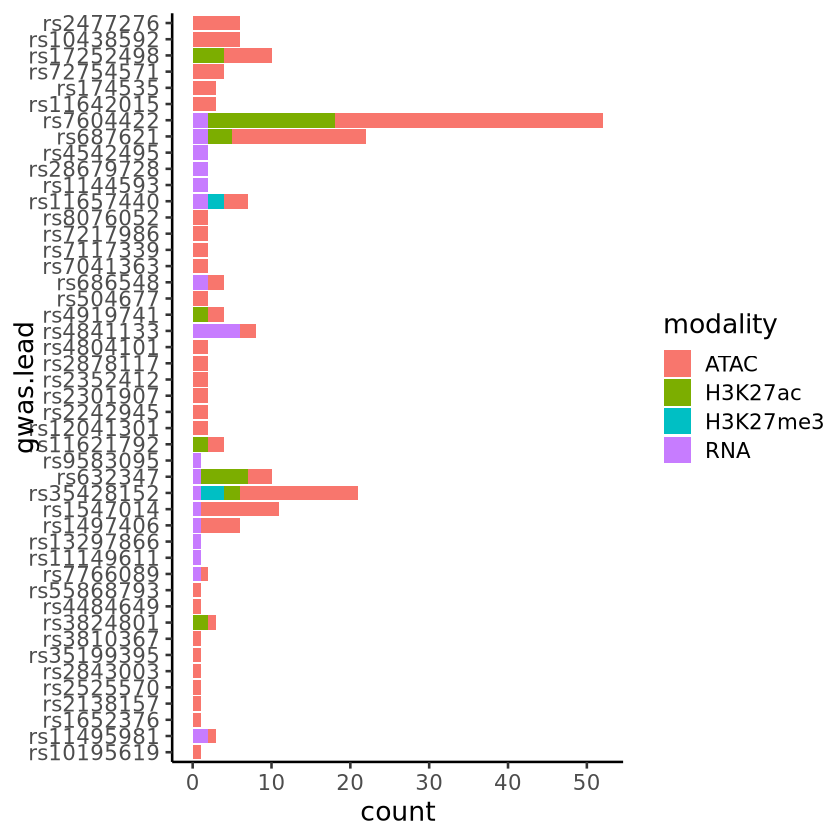

In [24]:
plot.data.var <- coloc.res.filt %>% group_by(modality, gwas.lead) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.var$gwas.lead <- factor(plot.data.var$gwas.lead, levels=unique(plot.data.var$gwas.lead))

ggplot(plot.data.var, aes(x=gwas.lead, y=count, fill=modality)) + geom_col() + theme_classic(base_size=16)  + coord_flip()

`summarise()` has grouped output by 'modality'. You can override using the `.groups` argument.


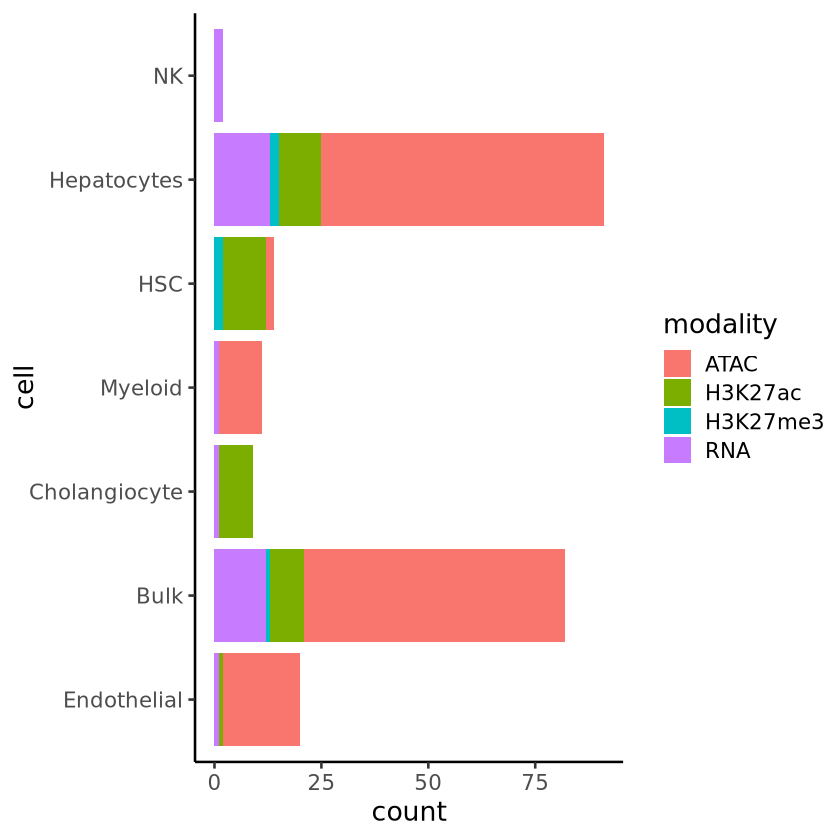

In [25]:
plot.data.ct <- coloc.res.filt %>% group_by(modality, cell) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.ct$cell <- factor(plot.data.ct$cell, levels=unique(plot.data.ct$cell))

ggplot(plot.data.ct, aes(x=cell, y=count, fill=modality)) + geom_col() + theme_classic(base_size=16)  + coord_flip()

In [26]:
arrange(coloc.res.filt, -PP.H4.abf)

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>
3412,5.172808e-07,4.360947e-05,3.938038e-05,0.002322378,0.9975941,Bulk,ATAC,chr14-24402430-24402730,rs11621792,3.560815e-09,24402720,rs11621792,1.114e-08,24402720
2832,7.092024e-41,3.947336e-09,7.629846e-35,0.003249932,0.9967501,Hepatocytes,ATAC,chr2-232655454-232655754,rs7604422,8.925568e-20,232645051,rs7604422,1.238e-12,232645051
2835,1.124735e-22,3.967666e-09,1.210029e-16,0.003271825,0.9967282,Hepatocytes,ATAC,chr2-232651647-232651947,rs7604422,4.459065e-15,232645051,rs7604422,1.238e-12,232645051
2832,9.835552e-18,4.069478e-09,1.058143e-11,0.003381468,0.9966185,Hepatocytes,ATAC,chr2-232654724-232655024,rs7604422,1.676369e-12,232645051,rs7604422,1.238e-12,232645051
3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,chr14-24402430-24402730,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720
2835,9.416104e-20,4.124916e-09,1.013017e-13,0.003441169,0.9965588,Bulk,ATAC,chr2-232651647-232651947,rs7604422,3.059650e-13,232645051,rs7604422,1.238e-12,232645051
2833,3.632772e-16,4.176360e-09,3.908262e-10,0.003496569,0.9965034,Hepatocytes,H3K27ac,chr2:232655093-232656092,rs11683367,6.056122e-12,232645301,rs7604422,1.238e-12,232645051
2833,3.632772e-16,4.176360e-09,3.908262e-10,0.003496569,0.9965034,HSC,H3K27ac,chr2:232655093-232656092,rs11683367,6.056122e-12,232645301,rs7604422,1.238e-12,232645051
2837,4.773806e-21,4.274958e-09,5.135826e-15,0.003602751,0.9963972,Hepatocytes,ATAC,chr2-232647251-232647551,rs11683367,5.906627e-14,232645301,rs7604422,1.238e-12,232645051


In [27]:
write.table(coloc.res, paste0(coloc.results.dir, '241205_WE_Full_Coloc_Summary_Stats.tsv'),
           sep='\t',col.names=T, row.names=F, quote=F)

In [28]:
write.table(coloc.res.filt, paste0(coloc.results.dir, '241205_WE_Full_Coloc_Summary_Stats_PP4_0.8.tsv'),
           sep='\t',col.names=T, row.names=F, quote=F)

In [29]:
library(LDlinkR)
# 6a35f8b05161

In [30]:
list_pop()

pop_code,super_pop_code,pop_name
<chr>,<chr>,<chr>
ALL,ALL,ALL POPULATIONS
AFR,AFR,AFRICAN
YRI,AFR,"Yoruba in Ibadan, Nigera"
LWK,AFR,"Luhya in Webuye, Kenya"
GWD,AFR,Gambian in Western Gambia
MSL,AFR,Mende in Sierra Leone
ESN,AFR,Esan in Nigera
ASW,AFR,Americans of African Ancestry in SW USA
ACB,AFR,African Carribbeans in Barbados


In [31]:
coloc.snps <- unique(c(coloc.res.filt$qtl.lead, coloc.res.filt$gwas.lead))
length(coloc.snps)
head(coloc.snps)

[1] 134

[1] "rs1497406"  "rs10916454" "rs2477276"  "rs174576"   "rs11607757"
[6] "rs9668670"

In [40]:
# Right now I am going snp pair by snp pair, but would be faster to go by chr I think
# Max 2.5k SNPs at once

coloc.res.filt$r2 <- 1

for (i in 1:nrow(coloc.res.filt)) {
    if (coloc.res.filt$qtl.lead[i] == coloc.res.filt$gwas.lead[i]) next
    
    ld.mat <- LDmatrix(c(coloc.res.filt$qtl.lead[i],coloc.res.filt$gwas.lead[i]), 
         pop = "EUR", 
         r2d = "r2", 
         token = '6a35f8b05161', 
         file = FALSE,
         genome_build = "grch38_high_coverage"
        ) %>% tibble::column_to_rownames(var='RS_number')
    
    if (nrow(ld.mat)==1) {
        ld.mat <- LDmatrix(c(coloc.res.filt$qtl.lead[i],coloc.res.filt$gwas.lead[i]), 
         pop = "EUR", 
         r2d = "r2", 
         token = '6a35f8b05161', 
         file = FALSE,
         genome_build = "grch37"
        ) %>% tibble::column_to_rownames(var='RS_number')
    }
    if (nrow(ld.mat)==1) {
        coloc.res.filt$r2[i] <- NA
    } else {
        coloc.res.filt$r2[i] <- ld.mat[coloc.res.filt$qtl.lead[i],coloc.res.filt$gwas.lead[i]]
    }
}


dim(coloc.res.filt)
head(coloc.res.filt)
table(coloc.res.filt$r2)


LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink server is working...



LDlink 

[1] 229  16

,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
1,2825,9.681856e-10,1.149327e-04,2.216742e-07,0.025340263,0.9745446,Bulk,ATAC,chr1-16189980-16190280,rs1497406,1.547193e-10,16178825,rs1497406,1.458e-08,16178825,1.000
2,2566,2.705990e-05,2.476040e-02,1.156288e-05,0.009614698,0.9655863,Bulk,ATAC,chr1-229256817-229257117,rs10916454,2.233151e-09,229253038,rs12041301,9.290e-06,229245010,0.816
3,5058,5.088451e-02,6.435270e-02,1.102903e-02,0.013087567,0.8606462,Bulk,ATAC,chr10-26710287-26710575,rs2477276,5.178316e-08,26666136,rs2477276,2.912e-05,26666136,1.000
4,5057,3.724166e-02,5.371677e-02,8.071817e-03,0.010752443,0.8902173,Bulk,ATAC,chr10-26711375-26711675,rs2477276,3.571726e-08,26666136,rs2477276,2.912e-05,26666136,1.000
5,2439,2.088562e-34,1.195832e-10,1.869171e-25,0.106127774,0.8938722,Bulk,ATAC,chr11-61820741-61821041,rs174576,2.043734e-17,61836038,rs174535,3.105e-15,61783884,0.911
6,2412,4.655157e-12,5.397353e-11,4.166160e-03,0.047355445,0.9484784,Bulk,ATAC,chr11-61832766-61833066,rs174576,4.284548e-07,61836038,rs174535,3.105e-15,61783884,0.911



    0 0.002 0.004 0.056 0.064 0.124 0.286 0.349  0.39 0.411 0.422 0.429 0.563 
    2     1     1     1     1     1     1     1     2     1     1     2     1 
0.582 0.615 0.698 0.706 0.713 0.716 0.719 0.737 0.766 0.778 0.792 0.795 0.816 
    1     1     4     1     1     1     6     1     1     1     1     2     2 
0.817 0.823 0.824 0.826 0.829  0.84 0.845  0.85 0.853 0.854 0.862 0.869  0.87 
    1     3     1     3     1     2     1     1     2     2     3    11     1 
0.873 0.881 0.883 0.888 0.899 0.903 0.908 0.911 0.914 0.917 0.918 0.919 0.932 
    8     5     1     2     1    12     6     2     2     1     2     1     2 
0.933 0.939  0.94 0.947 0.954 0.956 0.959 0.966 0.975 0.978 0.986 0.987 0.988 
    1     1     1     2     1    16     2     3     1     1     1     1    13 
 0.99 0.991 0.995     1 
    4     2     6    56 

In [41]:
sum(is.na(coloc.res.filt$r2))

[1] 1

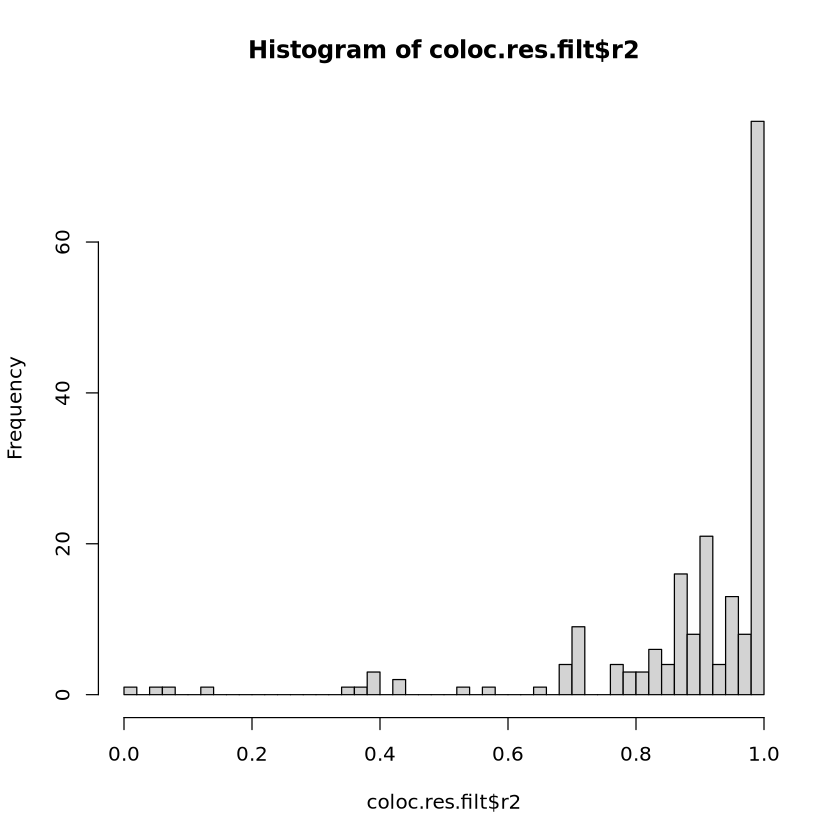

In [62]:
hist(coloc.res.filt$r2, breaks = 50)

In [43]:
coloc.res.filt.2 <- filter(coloc.res.filt, r2 > .8)

dim(coloc.res.filt.2)
head(coloc.res.filt.2)

[1] 191  16

,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
1,2825,9.681856e-10,1.149327e-04,2.216742e-07,0.025340263,0.9745446,Bulk,ATAC,chr1-16189980-16190280,rs1497406,1.547193e-10,16178825,rs1497406,1.458e-08,16178825,1.000
2,2566,2.705990e-05,2.476040e-02,1.156288e-05,0.009614698,0.9655863,Bulk,ATAC,chr1-229256817-229257117,rs10916454,2.233151e-09,229253038,rs12041301,9.290e-06,229245010,0.816
3,5058,5.088451e-02,6.435270e-02,1.102903e-02,0.013087567,0.8606462,Bulk,ATAC,chr10-26710287-26710575,rs2477276,5.178316e-08,26666136,rs2477276,2.912e-05,26666136,1.000
4,5057,3.724166e-02,5.371677e-02,8.071817e-03,0.010752443,0.8902173,Bulk,ATAC,chr10-26711375-26711675,rs2477276,3.571726e-08,26666136,rs2477276,2.912e-05,26666136,1.000
5,2439,2.088562e-34,1.195832e-10,1.869171e-25,0.106127774,0.8938722,Bulk,ATAC,chr11-61820741-61821041,rs174576,2.043734e-17,61836038,rs174535,3.105e-15,61783884,0.911
6,2412,4.655157e-12,5.397353e-11,4.166160e-03,0.047355445,0.9484784,Bulk,ATAC,chr11-61832766-61833066,rs174576,4.284548e-07,61836038,rs174535,3.105e-15,61783884,0.911


In [44]:
write.table(coloc.res.filt.2, paste0(coloc.results.dir, '241205_WE_Full_Coloc_Summary_Stats_PP4_0.8_r2_0.8.tsv'),
           sep='\t',col.names=T, row.names=F, quote=F)

In [45]:
coloc.res.filt.graph <- filter(coloc.res.filt.2, cell != 'Bulk')
dim(coloc.res.filt.graph)
head(coloc.res.filt.graph)

[1] 122  16

,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
1,2029,4.437728e-02,0.096384412,1.235239e-02,0.02600766,0.8208783,Endothelial,ATAC,chr16-3065114-3065414,rs55970600,4.193065e-07,3057948,rs10438592,3.855e-05,3060094,0.959
2,3704,3.693999e-04,0.118970546,1.172381e-04,0.03691459,0.8436282,Endothelial,ATAC,chr7-26101439-26101739,rs916964,4.423345e-09,26106443,rs35428152,5.824e-05,26118334,0.908
3,2942,9.670041e-04,0.004930162,9.719972e-03,0.04862043,0.9357624,Endothelial,ATAC,chr9-133185018-133185318,rs8176645,2.875564e-07,133273682,rs687621,1.170e-06,133261662,0.869
4,2942,7.654719e-05,0.004526702,7.694244e-04,0.04455068,0.9500766,Endothelial,ATAC,chr9-133186060-133186360,rs657152,1.726118e-08,133263862,rs687621,1.170e-06,133261662,0.881
5,2954,7.299339e-06,0.004766009,7.336999e-05,0.04695779,0.9481955,Endothelial,ATAC,chr9-133234106-133234406,rs8176645,1.163056e-08,133273682,rs687621,1.170e-06,133261662,0.869
6,2954,2.635643e-05,0.003742816,2.649242e-04,0.03666196,0.9593039,Endothelial,ATAC,chr9-133237267-133237567,rs8176645,5.398524e-08,133273682,rs687621,1.170e-06,133261662,0.869


In [46]:
sort(table(coloc.res.filt.graph$gwas.lead), decreasing = T)


 rs7604422 rs35428152   rs687621  rs1547014 rs11657440   rs632347 rs10438592 
        34         14         14          7          5          5          4 
 rs1497406  rs4841133 rs11621792  rs2477276  rs4919741 rs11642015   rs686548 
         4          4          3          3          3          2          2 
 rs1144593 rs11495981 rs12041301  rs1652376   rs174535  rs2352412  rs2525570 
         1          1          1          1          1          1          1 
 rs2843003 rs28679728  rs2878117 rs35199395  rs3810367  rs4484649  rs4542495 
         1          1          1          1          1          1          1 
 rs7041363  rs7117339 rs72754571  rs9583095 
         1          1          1          1 

In [47]:
length(unique(coloc.res.filt.graph$gwas.lead))

[1] 32

In [48]:
filter(coloc.res.filt.graph, feature=='CWF19L1')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>


`summarise()` has grouped output by 'modality'. You can override using the `.groups` argument.


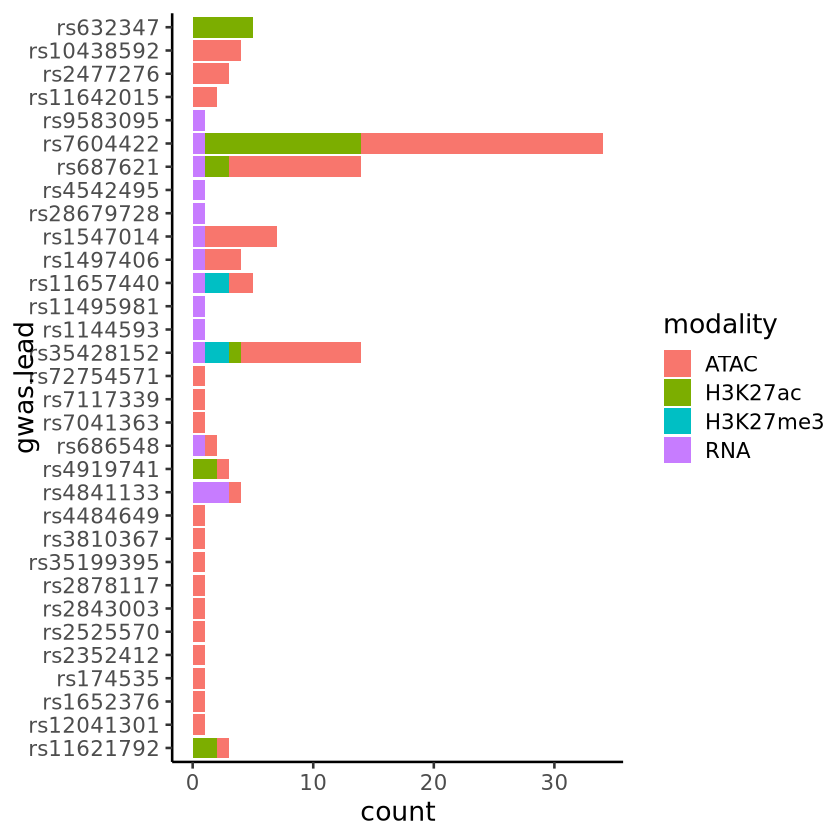

In [49]:
plot.data.var <- coloc.res.filt.graph %>% group_by(modality, gwas.lead) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.var$gwas.lead <- factor(plot.data.var$gwas.lead, levels=unique(plot.data.var$gwas.lead))

ggplot(plot.data.var, aes(x=gwas.lead, y=count, fill=modality)) + geom_col() + theme_classic(base_size=16)  + coord_flip()

`summarise()` has grouped output by 'modality', 'cell'. You can override using the `.groups` argument.


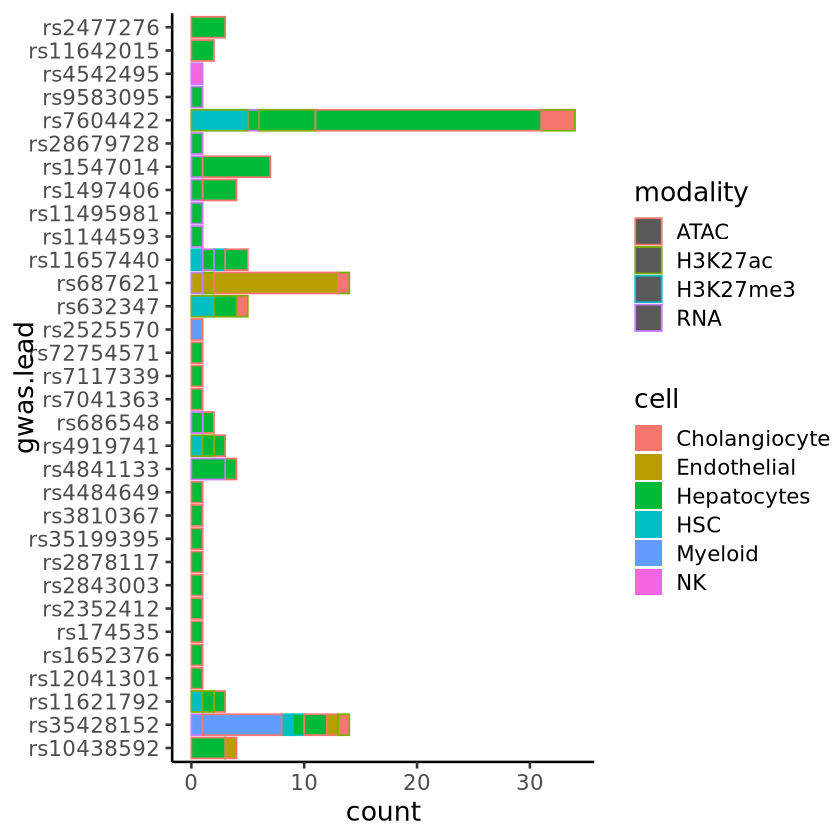

In [50]:
plot.data.var <- coloc.res.filt.graph %>% group_by(modality, cell, gwas.lead) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.var$gwas.lead <- factor(plot.data.var$gwas.lead, levels=unique(plot.data.var$gwas.lead))

ggplot(plot.data.var, aes(x=gwas.lead, y=count, fill=cell, color=modality)) + geom_col() + theme_classic(base_size=16)  + coord_flip()

`summarise()` has grouped output by 'modality', 'cell'. You can override using the `.groups` argument.


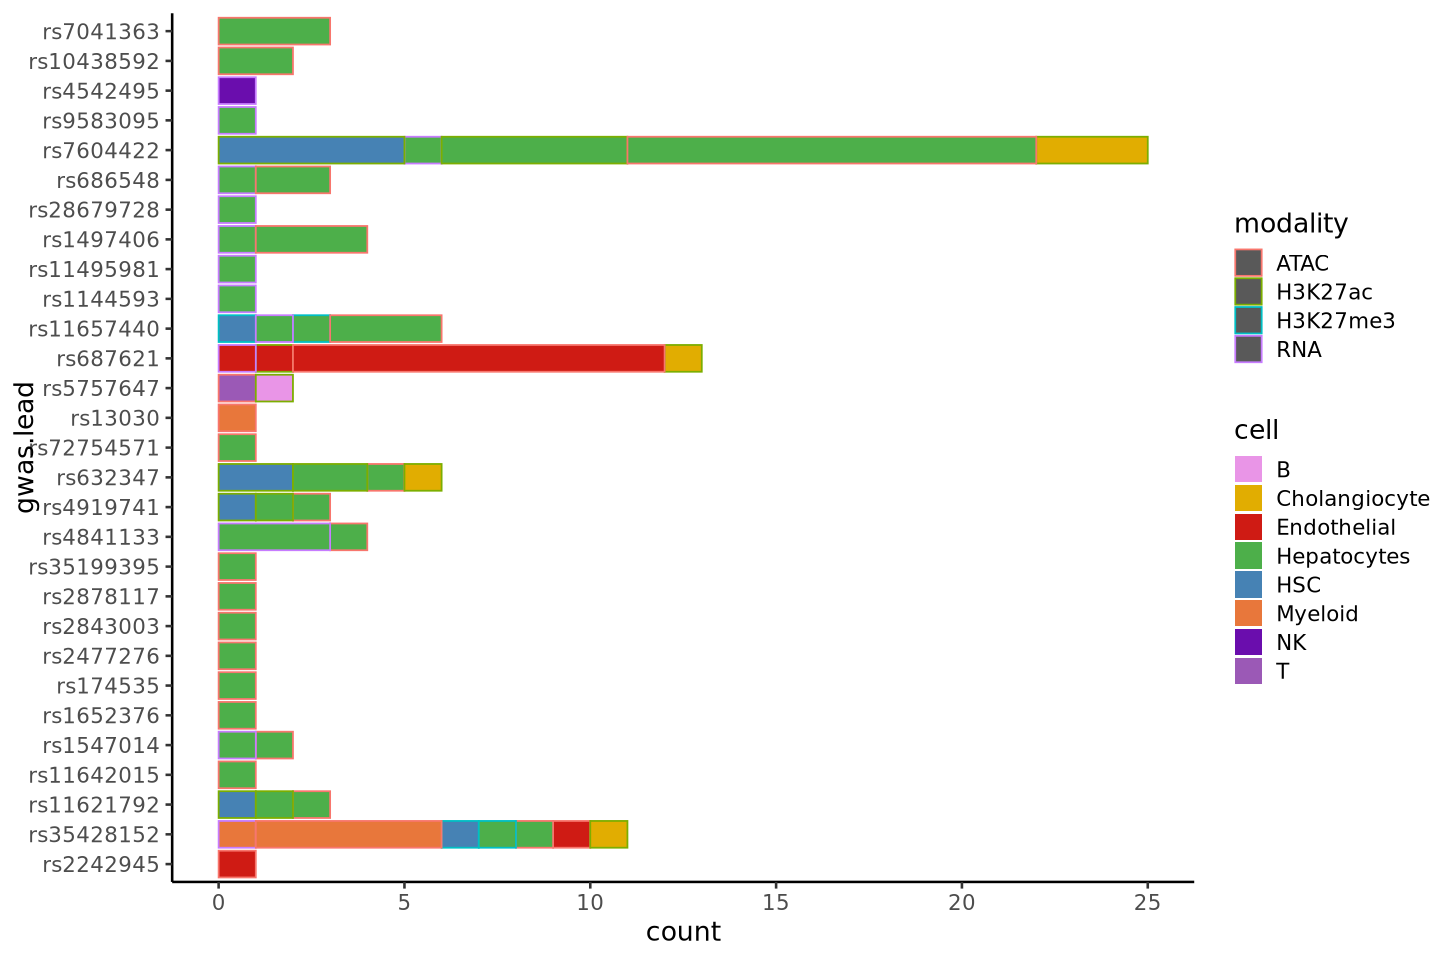

In [129]:
plot.data.var <- coloc.res.filt.graph %>% group_by(modality, cell, gwas.lead) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.var$gwas.lead <- factor(plot.data.var$gwas.lead, levels=unique(plot.data.var$gwas.lead))

ggplot(plot.data.var, aes(x=gwas.lead, y=count, fill=cell, color=modality)) + 
    geom_col() + 
    theme_classic(base_size=16) + 
    coord_flip() +
    scale_fill_manual(values=celltype_colors)

In [52]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

`summarise()` has grouped output by 'modality', 'cell'. You can override using the `.groups` argument.


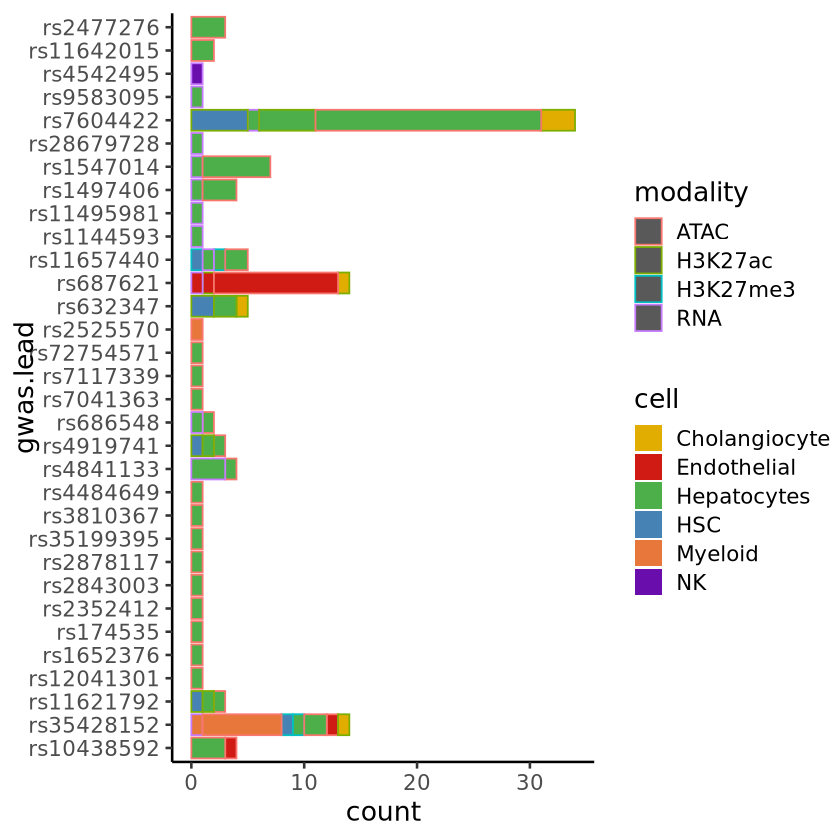

In [53]:
plot.data.var <- coloc.res.filt.graph %>% group_by(modality, cell, gwas.lead) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.var$gwas.lead <- factor(plot.data.var$gwas.lead, levels=unique(plot.data.var$gwas.lead))

ggplot(plot.data.var, aes(x=gwas.lead, y=count, fill=cell, color=modality)) + 
    geom_col() + 
    theme_classic(base_size=16) + 
    coord_flip() +
    scale_fill_manual(values=celltype_colors)

`summarise()` has grouped output by 'modality'. You can override using the `.groups` argument.


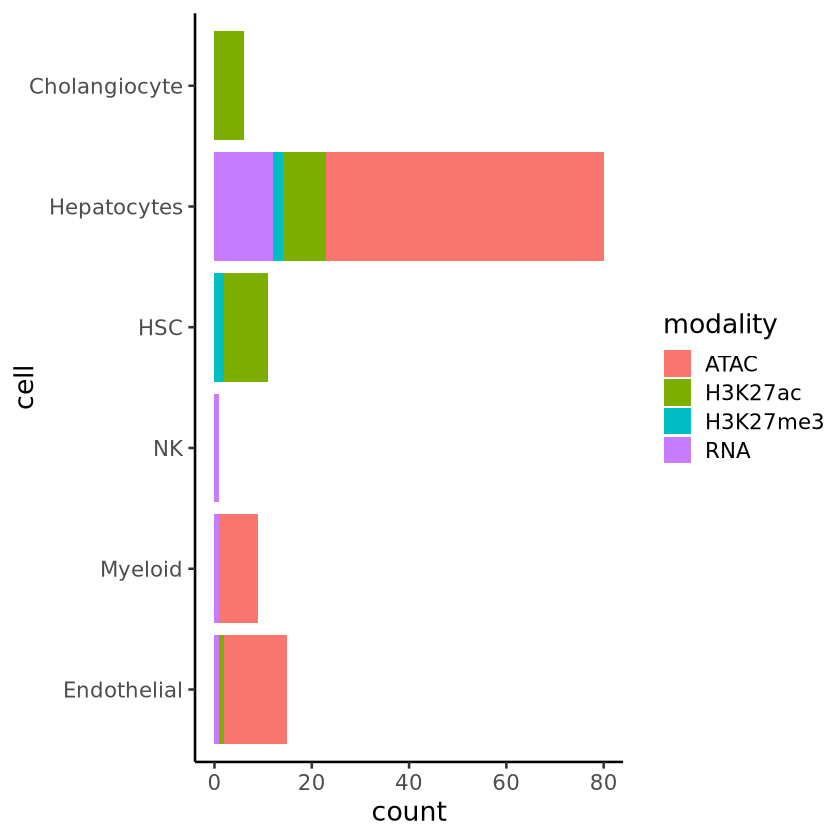

In [54]:
plot.data.ct <- coloc.res.filt.graph %>% group_by(modality, cell) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.ct$cell <- factor(plot.data.ct$cell, levels=unique(plot.data.ct$cell))

ggplot(plot.data.ct, aes(x=cell, y=count, fill=modality)) + geom_col() + theme_classic(base_size=16)  + coord_flip()

In [55]:
count.coloc <- group_by(coloc.res.filt.graph, cell) %>% summarise(n=n()) %>% arrange(n)
count.coloc

cell,n
<chr>,<int>
NK,1
Cholangiocyte,6
Myeloid,9
HSC,11
Endothelial,15
Hepatocytes,80


`summarise()` has grouped output by 'modality'. You can override using the `.groups` argument.


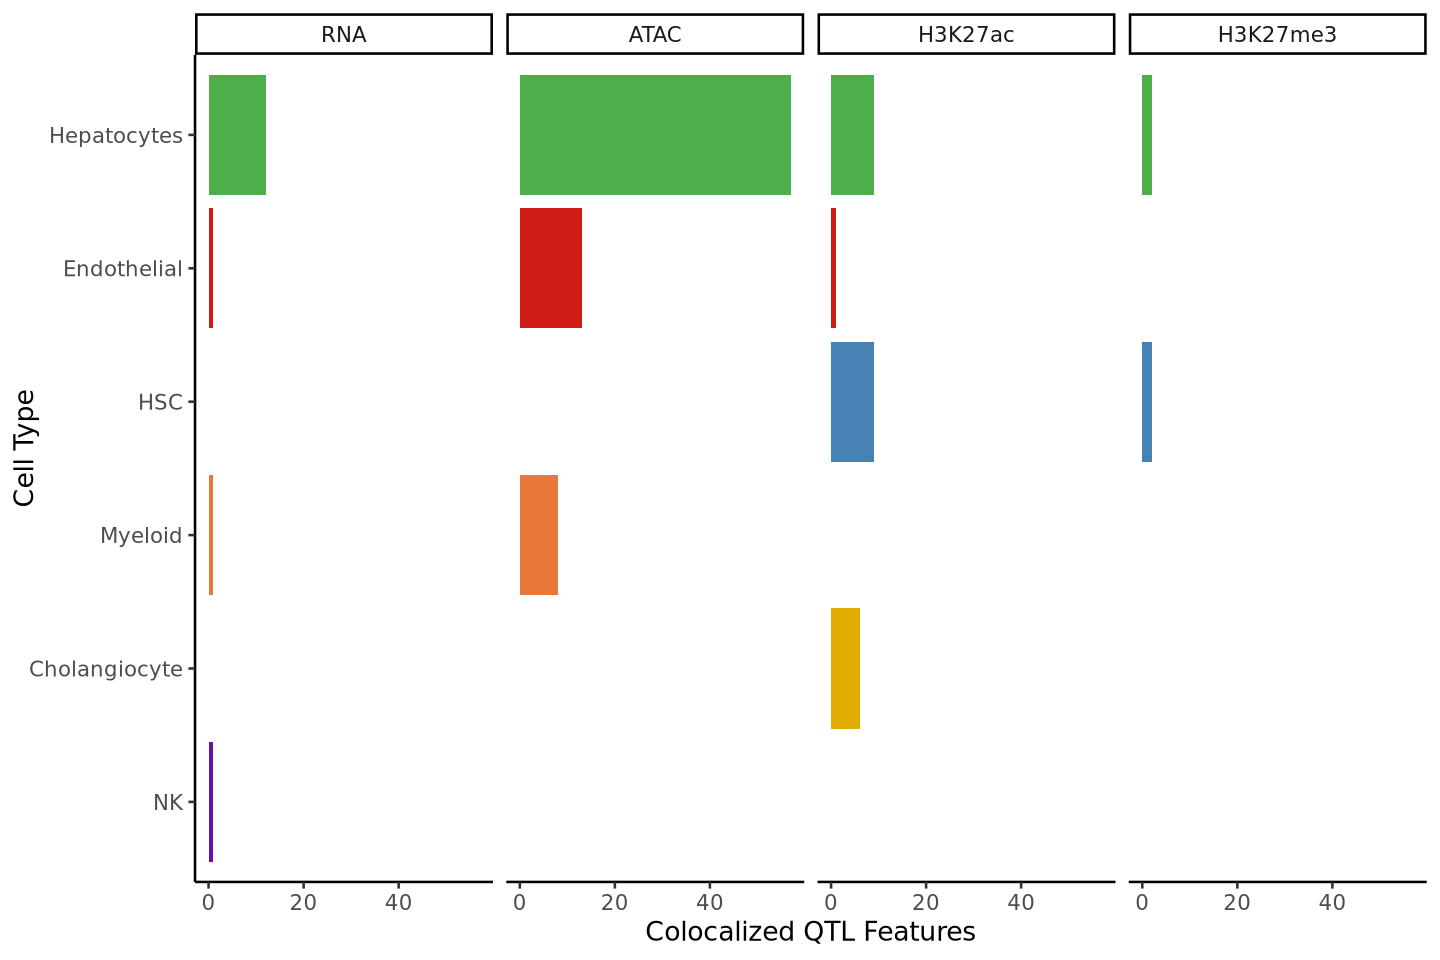

In [56]:
options(repr.plot.width=12, repr.plot.height=8)
plot.data.ct <- coloc.res.filt.graph %>% group_by(modality, cell) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.ct$cell <- factor(plot.data.ct$cell, levels=count.coloc$cell)
plot.data.ct$modality <- factor(plot.data.ct$modality, levels=c('RNA','ATAC','H3K27ac','H3K27me3'))

ggplot(plot.data.ct, aes(x=cell, y=count, fill=cell)) + 
    geom_col() + 
    theme_classic(base_size=16)  + 
    coord_flip() +
    facet_grid(~modality) +
    theme(legend.position="none") +
    labs(y='Colocalized QTL Features', x='     Cell Type') +
    scale_fill_manual(values=celltype_colors)

In [ ]:
# Direction of effect across modalities
# Ac/me are they promoter or enhancer focused

In [57]:
arrange(coloc.res.filt.graph, -PP.H4.abf)

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2832,7.092024e-41,3.947336e-09,7.629846e-35,0.003249932,0.9967501,Hepatocytes,ATAC,chr2-232655454-232655754,rs7604422,8.925568e-20,232645051,rs7604422,1.238e-12,232645051,1.000
2835,1.124735e-22,3.967666e-09,1.210029e-16,0.003271825,0.9967282,Hepatocytes,ATAC,chr2-232651647-232651947,rs7604422,4.459065e-15,232645051,rs7604422,1.238e-12,232645051,1.000
2832,9.835552e-18,4.069478e-09,1.058143e-11,0.003381468,0.9966185,Hepatocytes,ATAC,chr2-232654724-232655024,rs7604422,1.676369e-12,232645051,rs7604422,1.238e-12,232645051,1.000
3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,chr14-24402430-24402730,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720,1.000
2833,3.632772e-16,4.176360e-09,3.908262e-10,0.003496569,0.9965034,Hepatocytes,H3K27ac,chr2:232655093-232656092,rs11683367,6.056122e-12,232645301,rs7604422,1.238e-12,232645051,1.000
2833,3.632772e-16,4.176360e-09,3.908262e-10,0.003496569,0.9965034,HSC,H3K27ac,chr2:232655093-232656092,rs11683367,6.056122e-12,232645301,rs7604422,1.238e-12,232645051,1.000
2837,4.773806e-21,4.274958e-09,5.135826e-15,0.003602751,0.9963972,Hepatocytes,ATAC,chr2-232647251-232647551,rs11683367,5.906627e-14,232645301,rs7604422,1.238e-12,232645051,1.000
2833,1.160455e-16,4.326629e-09,1.248458e-10,0.003658396,0.9963416,Cholangiocyte,H3K27ac,chr2:232655093-232656092,rs11683367,7.477316e-12,232645301,rs7604422,1.238e-12,232645051,1.000
2838,3.119457e-16,4.345889e-09,3.356020e-10,0.003679138,0.9963209,Hepatocytes,ATAC,chr2-232668019-232668319,rs11683367,6.101996e-12,232645301,rs7604422,1.238e-12,232645051,1.000


In [109]:
filter(coloc.res.filt.graph, modality == 'H3K27me3')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
3541,0.0001627576,0.03893108,7.367008e-05,0.01667749,0.9441550,Hepatocytes,H3K27me3,chr17:81518095-81519594,rs11657440,1.213409e-08,81513660,rs11657440,2.189e-05,81513660,1.000
3705,0.0019110395,0.12215501,6.065264e-04,0.03793220,0.8373952,Hepatocytes,H3K27me3,chr7:26100917-26102416,rs916964,1.540124e-08,26106443,rs35428152,5.824e-05,26118334,0.908
3541,0.0001627576,0.03893108,7.367008e-05,0.01667749,0.9441550,HSC,H3K27me3,chr17:81518095-81519594,rs11657440,1.213409e-08,81513660,rs11657440,2.189e-05,81513660,1.000
3705,0.0019110395,0.12215501,6.065264e-04,0.03793220,0.8373952,HSC,H3K27me3,chr7:26100917-26102416,rs916964,1.540124e-08,26106443,rs35428152,5.824e-05,26118334,0.908


In [65]:
filter(coloc.res.filt.graph, cell == 'HSC')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
3760,4.930462e-14,5.028332e-10,9.037721e-07,0.008225348,0.9917737,HSC,H3K27ac,chr12:52884454-52885453,rs61927887,5.305787e-10,52883839,rs4919741,1.721e-13,52879136,0.991
3412,1.792524e-05,3.967540e-04,1.364642e-03,0.029235742,0.9689849,HSC,H3K27ac,chr14:24401916-24402915,rs11620783,7.502108e-09,24402324,rs11621792,1.114e-08,24402720,0.853
1638,2.061947e-02,7.278739e-02,1.400382e-02,0.048589934,0.8439994,HSC,H3K27ac,chr17:18477585-18478584,rs632759,2.376684e-06,18390254,rs632347,4.022e-05,18390196,1.000
1637,4.763536e-03,7.076940e-02,3.235120e-03,0.047188460,0.8740435,HSC,H3K27ac,chr17:18478811-18479810,rs632759,5.138280e-07,18390254,rs632347,4.022e-05,18390196,1.000
2850,5.100946e-09,5.767596e-09,5.487775e-03,0.005215684,0.9892965,HSC,H3K27ac,chr2:232634449-232635448,rs11683367,3.940325e-07,232645301,rs7604422,1.238e-12,232645051,1.000
2837,3.435776e-09,8.884121e-09,3.696327e-03,0.008570112,0.9877335,HSC,H3K27ac,chr2:232642518-232643517,rs11689178,1.283333e-07,232645141,rs7604422,1.238e-12,232645051,0.956
2838,2.612633e-12,5.734087e-09,2.810761e-06,0.005174107,0.9948231,HSC,H3K27ac,chr2:232646831-232647830,rs2140773,2.049336e-09,232648465,rs7604422,1.238e-12,232645051,0.988
2835,8.163481e-11,4.491032e-09,8.782557e-05,0.003835532,0.9960766,HSC,H3K27ac,chr2:232651359-232652358,rs11683367,2.570362e-08,232645301,rs7604422,1.238e-12,232645051,1.000
2833,3.632772e-16,4.176360e-09,3.908262e-10,0.003496569,0.9965034,HSC,H3K27ac,chr2:232655093-232656092,rs11683367,6.056122e-12,232645301,rs7604422,1.238e-12,232645051,1.000


In [58]:
filter(coloc.res.filt.graph, modality == 'H3K27me3')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
3541,0.0001627576,0.03893108,7.367008e-05,0.01667749,0.9441550,Hepatocytes,H3K27me3,chr17:81518095-81519594,rs11657440,1.213409e-08,81513660,rs11657440,2.189e-05,81513660,1.000
3705,0.0019110395,0.12215501,6.065264e-04,0.03793220,0.8373952,Hepatocytes,H3K27me3,chr7:26100917-26102416,rs916964,1.540124e-08,26106443,rs35428152,5.824e-05,26118334,0.908
3541,0.0001627576,0.03893108,7.367008e-05,0.01667749,0.9441550,HSC,H3K27me3,chr17:81518095-81519594,rs11657440,1.213409e-08,81513660,rs11657440,2.189e-05,81513660,1.000
3705,0.0019110395,0.12215501,6.065264e-04,0.03793220,0.8373952,HSC,H3K27me3,chr7:26100917-26102416,rs916964,1.540124e-08,26106443,rs35428152,5.824e-05,26118334,0.908


In [59]:
coloc.res.filt.graph.3 <- filter(coloc.res.filt.graph, gwas.pval < 5e-8)
coloc.res.filt.graph.3

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2866,7.785105e-09,5.311408e-04,1.782465e-06,0.120730410,0.8787367,Hepatocytes,ATAC,chr1-16179136-16179436,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2832,7.832685e-07,3.756671e-04,1.793359e-04,0.085097785,0.9143464,Hepatocytes,ATAC,chr1-16189049-16189288,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2825,4.295586e-14,2.657291e-04,9.835105e-12,0.059901085,0.9398332,Hepatocytes,ATAC,chr1-16189980-16190280,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
2439,4.226498e-35,2.134257e-11,3.782529e-26,0.018118780,0.9818812,Hepatocytes,ATAC,chr11-61820741-61821041,rs174536,1.015739e-17,61784455,rs174535,3.105e-15,61783884,0.978
3137,6.809861e-28,1.723499e-26,6.380127e-04,0.015163181,0.9841988,Hepatocytes,ATAC,chr11-94132939-94133200,rs11607757,1.160876e-08,94132981,rs7117339,2.256e-30,94137172,1.000
3759,1.174897e-33,8.672100e-09,2.153630e-26,0.158120960,0.8418790,Hepatocytes,ATAC,chr12-52884847-52885147,rs4919766,5.638330e-18,52873026,rs4919741,1.721e-13,52879136,0.899
3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,chr14-24402430-24402730,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720,1.000
3192,1.294632e-30,1.454103e-05,2.214677e-27,0.023898695,0.9760868,Hepatocytes,ATAC,chr15-89803942-89804242,rs72754570,5.933149e-19,89805748,rs72754571,2.467e-09,89807657,0.862
2691,2.604753e-07,2.112140e-04,2.420459e-04,0.195465879,0.8040806,Hepatocytes,ATAC,chr19-4327651-4327951,rs4435380,1.567333e-10,4335872,rs3810367,3.505e-09,4342850,0.826


In [60]:
sort(table(coloc.res.filt.graph.3$gwas.lead), decreasing = T)


 rs7604422  rs1547014  rs1497406  rs4841133 rs11621792  rs4919741   rs174535 
        34          7          4          4          3          3          1 
rs28679728  rs3810367  rs4484649  rs7041363  rs7117339 rs72754571 
         1          1          1          1          1          1 

`summarise()` has grouped output by 'modality', 'cell'. You can override using the `.groups` argument.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


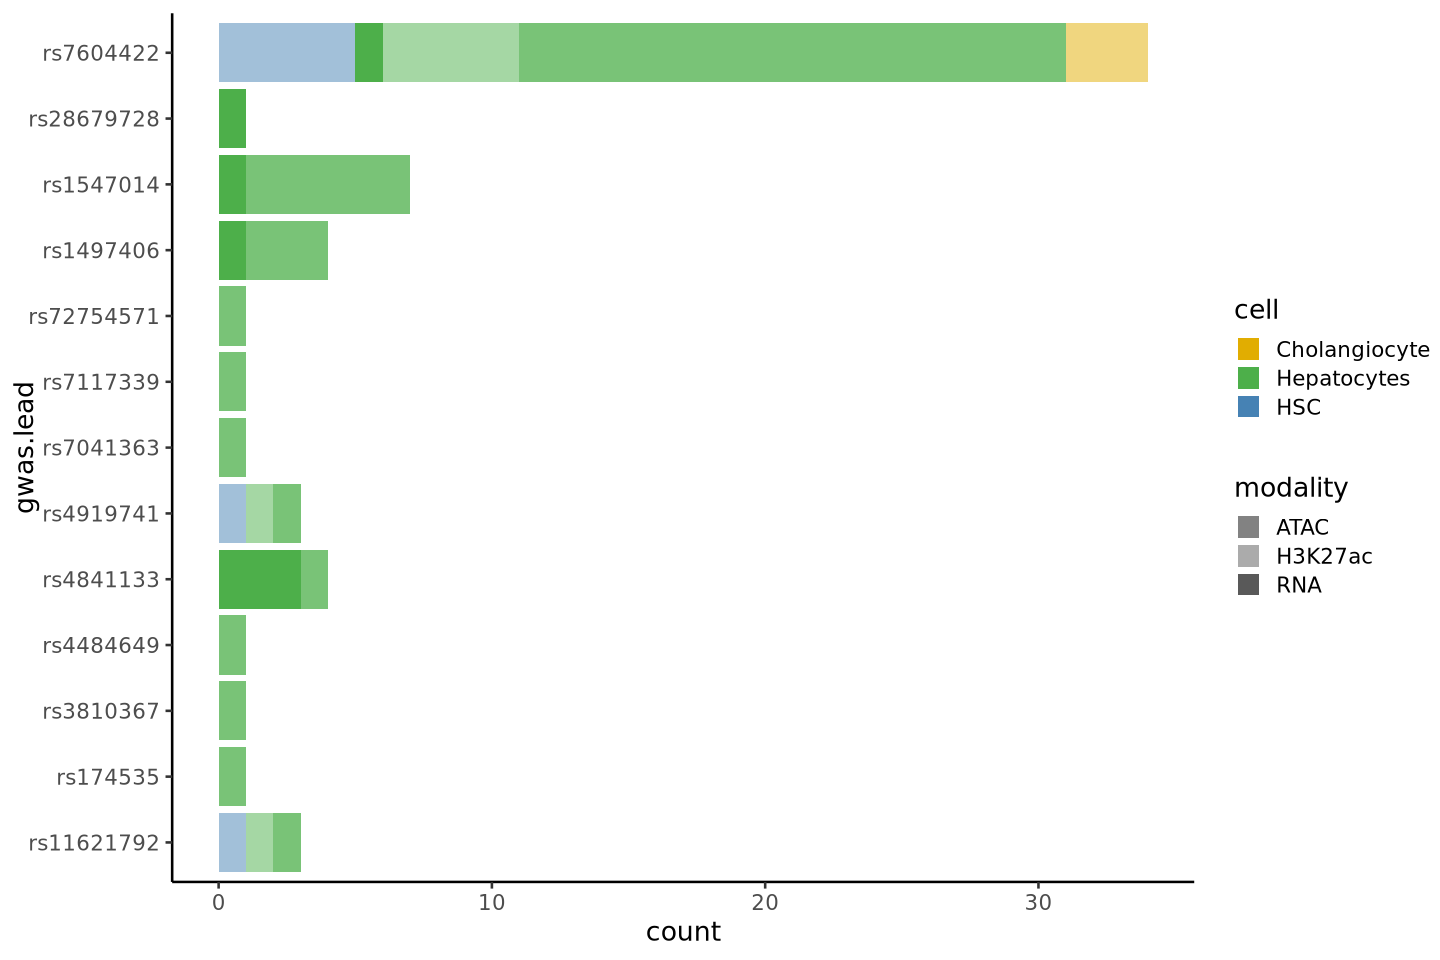

In [63]:
plot.data.var <- coloc.res.filt.graph.3 %>% group_by(modality, cell, gwas.lead) %>%
    summarise(count=n()) %>%
    arrange(count)
plot.data.var$gwas.lead <- factor(plot.data.var$gwas.lead, levels=unique(plot.data.var$gwas.lead))

ggplot(plot.data.var, aes(x=gwas.lead, y=count, fill=cell, alpha=modality)) + 
    geom_col(size=1.5) +
    theme_classic(base_size=16) + 
    coord_flip() +
    scale_fill_manual(values=celltype_colors) + 
    scale_alpha_manual(values = c(ATAC=.75, H3K27ac=.5, RNA=1)) 

In [66]:
filter(coloc.res.filt.graph.3, gwas.lead=='rs1497406')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2866,7.785105e-09,0.0005311408,1.782465e-06,0.12073041,0.8787367,Hepatocytes,ATAC,chr1-16179136-16179436,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2832,7.832685e-07,0.0003756671,1.793359e-04,0.08509779,0.9143464,Hepatocytes,ATAC,chr1-16189049-16189288,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2825,4.295586e-14,0.0002657291,9.835105e-12,0.05990109,0.9398332,Hepatocytes,ATAC,chr1-16189980-16190280,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
2921,3.793742e-06,0.0004743959,8.686089e-04,0.10772598,0.8909272,Hepatocytes,RNA,EPHA2,rs7538833,1.494710e-06,16177886,rs1497406,1.458e-08,16178825,0.824


In [67]:
filter(coloc.res.filt.graph.3, gwas.lead=='rs1547014')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
1790,7.312733e-16,1.911390e-12,2.662497e-06,0.005965157,0.9940322,Hepatocytes,ATAC,chr22-28708746-28709014,rs5752776,1.365146e-09,28712241,rs1547014,5.306e-16,28704723,0.995
1788,4.738769e-14,3.227631e-12,1.725341e-04,0.010762432,0.9890650,Hepatocytes,ATAC,chr22-28710094-28710394,rs2078555,1.177304e-08,28714771,rs1547014,5.306e-16,28704723,0.995
1787,2.571997e-13,6.034985e-12,9.364397e-04,0.020994737,0.9780688,Hepatocytes,ATAC,chr22-28710544-28710844,rs743184,1.256409e-07,28706979,rs1547014,5.306e-16,28704723,0.826
1785,2.167631e-15,1.622091e-11,7.892138e-06,0.058116913,0.9418752,Hepatocytes,ATAC,chr22-28712079-28712379,rs743184,1.493792e-09,28706979,rs1547014,5.306e-16,28704723,0.826
1771,8.553076e-13,4.634059e-12,3.114094e-03,0.015891174,0.9809947,Hepatocytes,ATAC,chr22-28732755-28733032,rs5752774,7.543230e-08,28709622,rs1547014,5.306e-16,28704723,1.000
1768,1.761002e-12,3.885670e-12,6.411640e-03,0.013166933,0.9804214,Hepatocytes,ATAC,chr22-28733791-28734091,rs1033667,5.898001e-07,28734312,rs1547014,5.306e-16,28704723,0.854
1783,6.292636e-14,2.605656e-12,2.291089e-04,0.008495672,0.9912752,Hepatocytes,RNA,CHEK2,rs5752775,4.526252e-07,28711207,rs1547014,5.306e-16,28704723,0.995


In [68]:
write.table(coloc.res.filt.graph.3, paste0(coloc.results.dir, '241205_WE_Full_Coloc_Summary_Stats_PP4_0.8_r2_0.8_gwas_sig.tsv'),
           sep='\t',col.names=T, row.names=F, quote=F)

In [ ]:
coloc.results.dir

In [ ]:
/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/coloc.res/241205_WE_Full_Coloc_Summary_Stats_PP4_0.8_r2_0.8_gwas_sig.tsv

In [3]:
coloc.results.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/coloc.res/'
coloc.res.filt.graph.3 <- read.table(paste0(coloc.results.dir, '241205_WE_Full_Coloc_Summary_Stats_PP4_0.8_r2_0.8_gwas_sig.tsv'),
                                    header=T)
coloc.res.filt.graph.3

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2866,7.785105e-09,5.311408e-04,1.782465e-06,0.120730410,0.8787367,Hepatocytes,ATAC,chr1-16179136-16179436,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2832,7.832685e-07,3.756671e-04,1.793359e-04,0.085097785,0.9143464,Hepatocytes,ATAC,chr1-16189049-16189288,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2825,4.295586e-14,2.657291e-04,9.835105e-12,0.059901085,0.9398332,Hepatocytes,ATAC,chr1-16189980-16190280,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
2439,4.226498e-35,2.134257e-11,3.782529e-26,0.018118780,0.9818812,Hepatocytes,ATAC,chr11-61820741-61821041,rs174536,1.015739e-17,61784455,rs174535,3.105e-15,61783884,0.978
3137,6.809861e-28,1.723499e-26,6.380127e-04,0.015163181,0.9841988,Hepatocytes,ATAC,chr11-94132939-94133200,rs11607757,1.160876e-08,94132981,rs7117339,2.256e-30,94137172,1.000
3759,1.174897e-33,8.672100e-09,2.153630e-26,0.158120960,0.8418790,Hepatocytes,ATAC,chr12-52884847-52885147,rs4919766,5.638330e-18,52873026,rs4919741,1.721e-13,52879136,0.899
3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,chr14-24402430-24402730,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720,1.000
3192,1.294632e-30,1.454103e-05,2.214677e-27,0.023898695,0.9760868,Hepatocytes,ATAC,chr15-89803942-89804242,rs72754570,5.933149e-19,89805748,rs72754571,2.467e-09,89807657,0.862
2691,2.604753e-07,2.112140e-04,2.420459e-04,0.195465879,0.8040806,Hepatocytes,ATAC,chr19-4327651-4327951,rs4435380,1.567333e-10,4335872,rs3810367,3.505e-09,4342850,0.826


In [5]:
table(select(coloc.res.filt.graph.3, gwas.lead, modality))

            modality
gwas.lead    ATAC H3K27ac RNA
  rs11621792    1       2   0
  rs1497406     3       0   1
  rs1547014     6       0   1
  rs174535      1       0   0
  rs28679728    0       0   1
  rs3810367     1       0   0
  rs4484649     1       0   0
  rs4841133     1       0   3
  rs4919741     1       2   0
  rs7041363     1       0   0
  rs7117339     1       0   0
  rs72754571    1       0   0
  rs7604422    20      13   1

In [19]:
filter(coloc.res.filt.graph.3, cell != 'Hepatocytes')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2838,9.355513e-12,4.779962e-09,1.006499e-05,0.004146606,0.9958433,Cholangiocyte,H3K27ac,chr2:232646831-232647830,rs2140773,4.579463e-09,232648465,rs7604422,1.238e-12,232645051,0.988
2833,1.160455e-16,4.326629e-09,1.248458e-10,0.003658396,0.9963416,Cholangiocyte,H3K27ac,chr2:232655093-232656092,rs11683367,7.477316e-12,232645301,rs7604422,1.238e-12,232645051,1.000
2835,1.749706e-12,8.750446e-09,1.882395e-06,0.008422458,0.9915757,Cholangiocyte,H3K27ac,chr2:232656697-232657696,rs11689178,2.004765e-09,232645141,rs7604422,1.238e-12,232645051,0.956
3760,4.930462e-14,5.028332e-10,9.037721e-07,0.008225348,0.9917737,HSC,H3K27ac,chr12:52884454-52885453,rs61927887,5.305787e-10,52883839,rs4919741,1.721e-13,52879136,0.991
3412,1.792524e-05,3.967540e-04,1.364642e-03,0.029235742,0.9689849,HSC,H3K27ac,chr14:24401916-24402915,rs11620783,7.502108e-09,24402324,rs11621792,1.114e-08,24402720,0.853
2850,5.100946e-09,5.767596e-09,5.487775e-03,0.005215684,0.9892965,HSC,H3K27ac,chr2:232634449-232635448,rs11683367,3.940325e-07,232645301,rs7604422,1.238e-12,232645051,1.000
2837,3.435776e-09,8.884121e-09,3.696327e-03,0.008570112,0.9877335,HSC,H3K27ac,chr2:232642518-232643517,rs11689178,1.283333e-07,232645141,rs7604422,1.238e-12,232645051,0.956
2838,2.612633e-12,5.734087e-09,2.810761e-06,0.005174107,0.9948231,HSC,H3K27ac,chr2:232646831-232647830,rs2140773,2.049336e-09,232648465,rs7604422,1.238e-12,232645051,0.988
2835,8.163481e-11,4.491032e-09,8.782557e-05,0.003835532,0.9960766,HSC,H3K27ac,chr2:232651359-232652358,rs11683367,2.570362e-08,232645301,rs7604422,1.238e-12,232645051,1.000


In [103]:
plot.coloc.data <- distinct(select(coloc.res.filt.graph.3, gwas.lead, modality))
plot.coloc.data$label <- ''
plot.coloc.data[plot.coloc.data$gwas.lead=='rs7604422' & plot.coloc.data$modality == 'H3K27ac',]$label <- '**'
plot.coloc.data[plot.coloc.data$gwas.lead=='rs11621792' & plot.coloc.data$modality == 'H3K27ac',]$label <- '*'
plot.coloc.data[plot.coloc.data$gwas.lead=='rs4919741' & plot.coloc.data$modality == 'H3K27ac',]$label <- '*'

plot.coloc.data

gwas.lead,modality,label
<chr>,<chr>,<chr>
rs1497406,ATAC,
rs174535,ATAC,
rs7117339,ATAC,
rs4919741,ATAC,
rs11621792,ATAC,
rs72754571,ATAC,
rs3810367,ATAC,
rs7604422,ATAC,
rs1547014,ATAC,


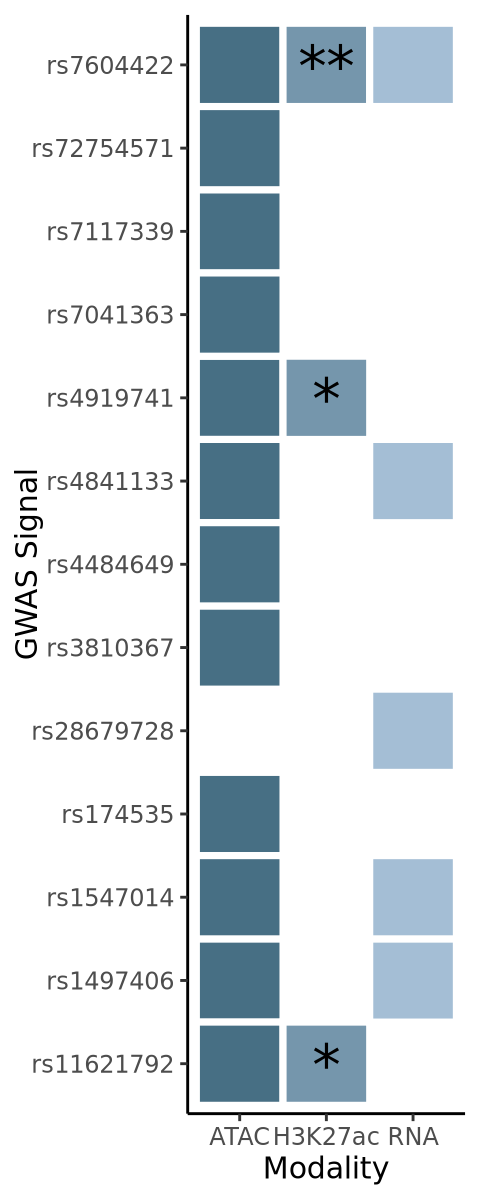

In [104]:
options(repr.plot.width=4, repr.plot.height=10)
ggplot(plot.coloc.data, aes(x=modality, y=gwas.lead, fill=modality)) + 
    geom_tile(color = "white", lwd = 2) + scale_fill_manual(values = rev(c('#A4BED5','#7596AC','#476F84'))) +#,'#245363','#023743'))) + 
    theme_classic(base_size=18) + 
    labs(x='Modality',y='GWAS Signal') + 
    geom_text(aes(label=label), size=12) + 
    theme(legend.position = 'None')

In [106]:
options(repr.plot.width=4, repr.plot.height=10)
p1 <- ggplot(plot.coloc.data, aes(x=modality, y=gwas.lead, fill=modality)) + 
    geom_tile(color = "white", lwd = 2) + scale_fill_manual(values = rev(c('#A4BED5','#7596AC','#476F84'))) +#,'#245363','#023743'))) + 
    theme_classic(base_size=18) + 
    labs(x='Modality',y='GWAS Signal') + 
    geom_text(aes(label=label), size=12) + 
    theme(legend.position = 'None') 

ggsave(p1, filename='/nfs/lab/welison/Liver/Plots/241212_WE_Coloc_annot.pdf', width=4, height=10)

In [80]:
?reframe

In [107]:
plot.coloc.data <- distinct(select(coloc.res.filt.graph.3, gwas.lead, modality))
plot.coloc.data$label <- 'Hepatocytes'
plot.coloc.data[plot.coloc.data$gwas.lead=='rs7604422' & plot.coloc.data$modality == 'H3K27ac',]$label <- 'Hepatocytes,HSC,Cholangiocytes'
plot.coloc.data[plot.coloc.data$gwas.lead=='rs11621792' & plot.coloc.data$modality == 'H3K27ac',]$label <- 'Hepatocytes,HSC'
plot.coloc.data[plot.coloc.data$gwas.lead=='rs4919741' & plot.coloc.data$modality == 'H3K27ac',]$label <- 'Hepatocytes,HSC'

plot.coloc.data

gwas.lead,modality,label
<chr>,<chr>,<chr>
rs1497406,ATAC,Hepatocytes
rs174535,ATAC,Hepatocytes
rs7117339,ATAC,Hepatocytes
rs4919741,ATAC,Hepatocytes
rs11621792,ATAC,Hepatocytes
rs72754571,ATAC,Hepatocytes
rs3810367,ATAC,Hepatocytes
rs7604422,ATAC,Hepatocytes
rs1547014,ATAC,Hepatocytes


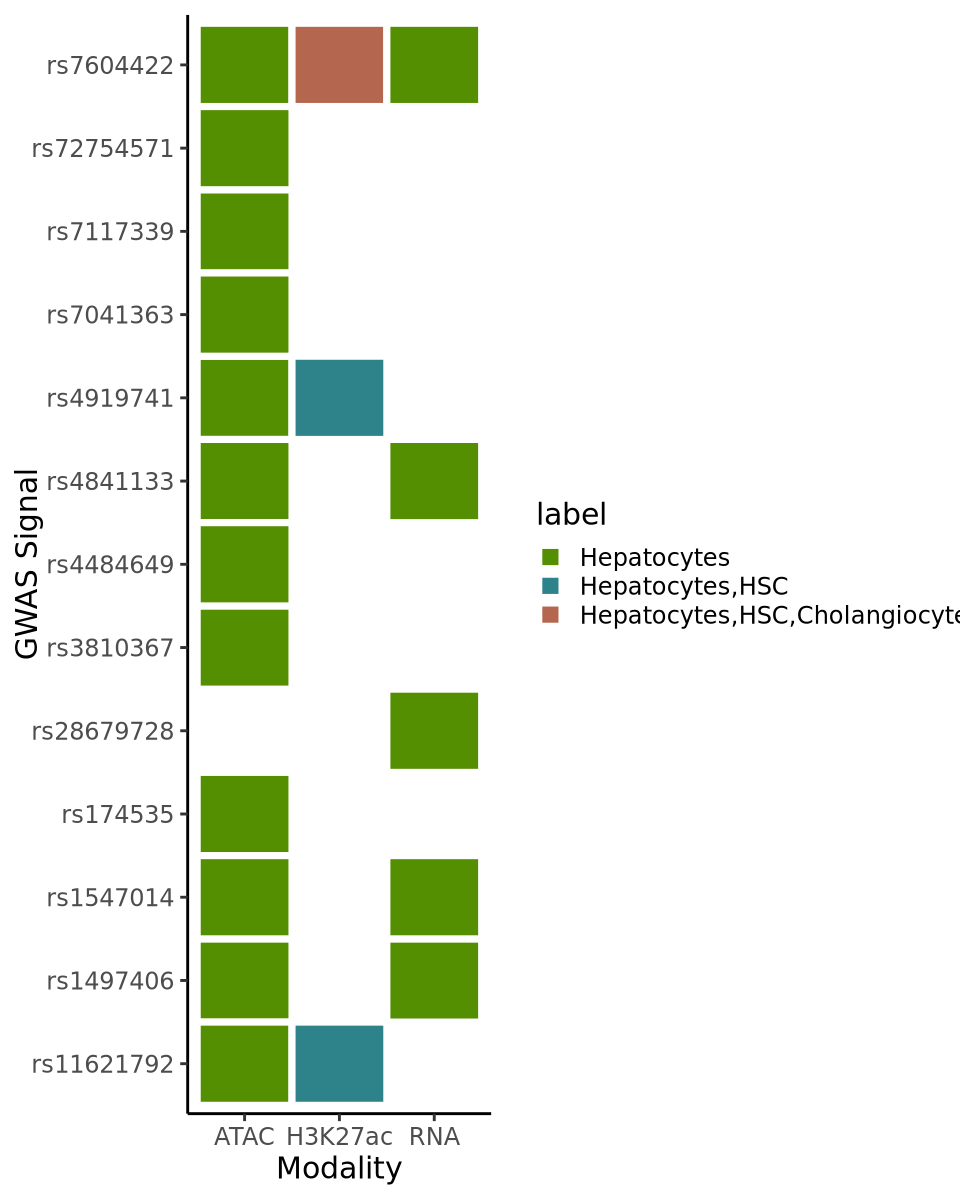

In [108]:
options(repr.plot.width=8, repr.plot.height=10)
ggplot(plot.coloc.data, aes(x=modality, y=gwas.lead, fill=label)) + #c("#91D5DE", "#2E8289", "#B4674E", "#EAAE37", "#565F41")
    geom_tile(color = "white", lwd = 2) + scale_fill_manual(values = rev(c('#B4674E','#2E8289','#548F01'))) +
    theme_classic(base_size=18) + 
    labs(x='Modality',y='GWAS Signal')

In [110]:
p1 <- ggplot(plot.coloc.data, aes(x=modality, y=gwas.lead, fill=label)) + #c("#91D5DE", "#2E8289", "#B4674E", "#EAAE37", "#565F41")
    geom_tile(color = "white", lwd = 2) + scale_fill_manual(values = rev(c('#B4674E','#2E8289','#548F01'))) +
    theme_classic(base_size=18) + 
    labs(x='Modality',y='GWAS Signal')

ggsave(p1, filename='/nfs/lab/welison/Liver/Plots/241212_WE_Coloc_color.pdf', width=8, height=10)

In [10]:
filter(coloc.res.filt.graph.3, modality=='RNA')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2921,3.793742e-06,4.743959e-04,8.686089e-04,0.107725977,0.8909272,Hepatocytes,RNA,EPHA2,rs7538833,1.494710e-06,16177886,rs1497406,1.458e-08,16178825,0.824
2900,3.743305e-20,4.374975e-09,4.027177e-14,0.003710461,0.9962895,Hepatocytes,RNA,EFHD1,rs7604500,1.437833e-13,232645081,rs7604422,1.238e-12,232645051,1.000
1783,6.292636e-14,2.605656e-12,2.291089e-04,0.008495672,0.9912752,Hepatocytes,RNA,CHEK2,rs5752775,4.526252e-07,28711207,rs1547014,5.306e-16,28704723,0.995
3692,7.384385e-23,9.290130e-21,1.901216e-04,0.022941903,0.9768680,Hepatocytes,RNA,HSD17B13,rs10433879,4.735815e-08,87309988,rs28679728,5.188e-25,87265289,0.954
4698,1.532066e-20,2.914450e-20,1.884062e-02,0.034894256,0.9462651,Hepatocytes,RNA,AC022784.1,rs2126263,2.191510e-07,9324101,rs4841133,1.015e-24,9326154,0.873
5076,1.081912e-20,2.078924e-20,1.330484e-02,0.024603528,0.9620916,Hepatocytes,RNA,AC021736.1,rs2126263,1.716854e-07,9324101,rs4841133,1.015e-24,9326154,0.873
5071,9.301202e-23,2.643452e-20,1.143818e-04,0.031539568,0.9683461,Hepatocytes,RNA,AC021242.2,rs2126263,8.360653e-10,9324101,rs4841133,1.015e-24,9326154,0.873


In [11]:
filter(coloc.res.filt.graph.3, modality=='ATAC' & gwas.lead=='rs7604422')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2857,3.147337e-11,4.963771e-09,3.386015e-05,0.004344576,0.9956216,Hepatocytes,ATAC,chr2-232630285-232630522,rs2140773,3.129548e-08,232648465,rs7604422,1.238e-12,232645051,0.988
2852,5.825289e-13,4.502646e-09,6.267048e-07,0.003847952,0.9961514,Hepatocytes,ATAC,chr2-232633359-232633659,rs11683367,2.610760e-09,232645301,rs7604422,1.238e-12,232645051,1.000
2850,6.120780e-14,6.806535e-09,6.584948e-08,0.006329036,0.9936709,Hepatocytes,ATAC,chr2-232634360-232634660,rs11689178,3.808140e-11,232645141,rs7604422,1.238e-12,232645051,0.956
2850,1.141901e-14,6.057141e-09,1.228497e-08,0.005522005,0.9944780,Hepatocytes,ATAC,chr2-232634838-232635138,rs11689178,1.529645e-11,232645141,rs7604422,1.238e-12,232645051,0.956
2837,5.718959e-18,4.638630e-09,6.152655e-12,0.003994393,0.9960056,Hepatocytes,ATAC,chr2-232642898-232643198,rs11683367,2.664041e-13,232645301,rs7604422,1.238e-12,232645051,1.000
2837,1.678744e-20,4.269696e-09,1.806052e-14,0.003597085,0.9964029,Hepatocytes,ATAC,chr2-232647213-232647513,rs11683367,9.836419e-14,232645301,rs7604422,1.238e-12,232645051,1.000
2832,7.843163e-38,3.948455e-09,8.437947e-32,0.003251136,0.9967489,Hepatocytes,ATAC,chr2-232655472-232655697,rs7604422,3.790168e-19,232645051,rs7604422,1.238e-12,232645051,1.000
2836,4.607006e-22,4.572983e-09,4.956377e-16,0.003923697,0.9960763,Hepatocytes,ATAC,chr2-232658271-232658571,rs2140773,6.769846e-15,232648465,rs7604422,1.238e-12,232645051,0.988
2838,5.517444e-14,4.368508e-09,5.935858e-08,0.003703496,0.9962964,Hepatocytes,ATAC,chr2-232667947-232668247,rs11683367,1.109020e-10,232645301,rs7604422,1.238e-12,232645051,1.000
